True equation: y = 3x + 2 ± random(0,1)
True: m = 3.0000,  b = 2.0000

My LS: m = 2.9154,  b = 2.1049
NumPy: m = 2.9154,  b = 2.1049
True m - My LS & NumPy m = 0.0846
True b - My LS & NumPy b = 0.1049

My Residual   NumPy Residual
0.6349        0.6349
-0.5980        -0.5980
0.1896        0.1896
0.1216        0.1216
0.3022        0.3022
-0.5013        -0.5013
-0.3804        -0.3804
-0.7624        -0.7624
-0.4767        -0.4767
0.0335        0.0335
0.4910        0.4910
-0.2703        -0.2703
0.0231        0.0231
0.8312        0.8312
0.3119        0.3119
-0.7054        -0.7054
-0.0073        -0.0073
0.2278        0.2278
-0.7965        -0.7965
-0.4464        -0.4464
0.6724        0.6724
0.4839        0.4839
0.1642        0.1642
0.8858        0.8858
0.2478        0.2478
0.3507        0.3507
0.0726        0.0726
-0.2763        -0.2763
-0.8630        -0.8630
-0.9491        -0.9491
-0.6809        -0.6809
-1.0324        -1.0324
0.7081        0.7081
0.3678        0.3678
0.2672        0.2672
-0.0

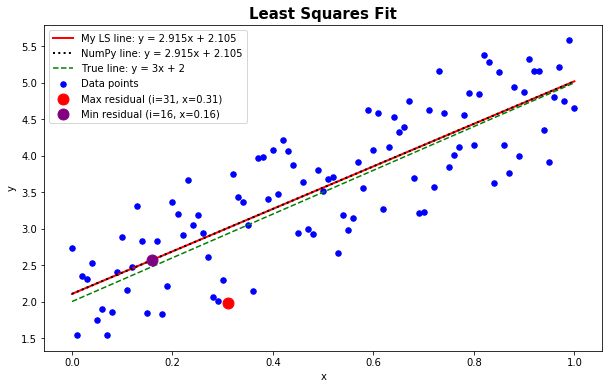

In [60]:
import numpy as np
import matplotlib.pyplot as plt

#my function
def my_least_squares(x, y):
    n = len(x)
    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_xy = np.sum(x * y)
    sum_xx = np.sum(x * x)

    m = (n * sum_xy - sum_x * sum_y) / (n * sum_xx - sum_x**2)
    b = (sum_y - m * sum_x) / n
    return m, b

trueM = 3
trueB = 2

# printing
print(f"True equation: y = {trueM}x + {trueB} ± random(0,1)")

x = np.arange(0, 1.01, 0.01)
signs = np.random.choice([-1, 1], len(x))
noise = signs * np.random.uniform(0, 1, len(x))
y = TRUE_M * x + TRUE_B + noise

my_m2, my_b2 = my_least_squares(x, y)

A2 = np.vstack([x, np.ones(len(x))]).T
np_m2, np_b2 = np.linalg.lstsq(A2, y, rcond=None)[0]

print(f"True: m = {TRUE_M:.4f},  b = {TRUE_B:.4f}")
print(f"\nMy LS: m = {my_m2:.4f},  b = {my_b2:.4f}")
print(f"NumPy: m = {np_m2:.4f},  b = {np_b2:.4f}")
print(f"True m - My LS & NumPy m = {abs(my_m2 - TRUE_M):.4f}")
print(f"True b - My LS & NumPy b = {abs(my_b2 - TRUE_B):.4f}")

# residuals for both methods
my_y_pred = my_m2 * x + my_b2
np_y_pred = np_m2 * x + np_b2

my_residuals = y - my_y_pred
np_residuals = y - np_y_pred

my_max = np.argmax(np.abs(my_residuals))
my_min = np.argmin(np.abs(my_residuals))
np_max = np.argmax(np.abs(np_residuals))
np_min = np.argmin(np.abs(np_residuals))

# printing
print()
print(f"{'My Residual':}   {'NumPy Residual':}")
for i in range(len(x)):
    print(f"{my_residuals[i]:.4f}        {np_residuals[i]:.4f}")
print()
print(f"My LS: Largest  residual: x={x[my_max]:.2f}, residual={my_residuals[my_max]:.4f}")
print(f"My LS: Smallest residual: x={x[my_min]:.2f}, residual={my_residuals[my_min]:.4f}")
print(f"NumPy: Largest  residual: x={x[np_max]:.2f}, residual={np_residuals[np_max]:.4f}")
print(f"NumPy: Smallest residual: x={x[np_min]:.2f}, residual={np_residuals[np_min]:.4f}")

# plotting
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='blue', s=30, label='Data points')
plt.plot(x, my_y_pred, color='red', linewidth=2, label=f'My LS line: y = {my_m2:.3f}x + {my_b2:.3f}')
plt.plot(x, np_y_pred, color='black', linewidth=2, linestyle=':', label=f'NumPy line: y = {np_m2:.3f}x + {np_b2:.3f}')
plt.plot(x, TRUE_M * x + TRUE_B, color='green', linewidth=1.5, linestyle='--', label=f'True line: y = {TRUE_M}x + {TRUE_B}')
plt.scatter(x[my_max], y[my_max], color='red', s=120, zorder=5, label=f'Max residual (i={my_max}, x={x[my_max]:.2f})')
plt.scatter(x[my_min], y[my_min], color='purple', s=120, zorder=5, label=f'Min residual (i={my_min}, x={x[my_min]:.2f})')
plt.title('Least Squares Fit', fontsize=15, fontweight='bold')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()